# Birkhoff Contraction on the Three-State Simplex

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2026 Gabriel Peyré. Released under the MIT License; see the repository LICENSE file.

This notebook generates the figure labeled fig:sinkhorn-birkhoff-simplex-contraction. It illustrates the Birkhoff--Hopf contraction theorem for three strictly positive Markov operators acting on the probability simplex

$$
\Sigma_3=\left\{a\in\mathbb R_+^3:\mathbf 1^\top a=1\right\}.
$$

Histograms are column vectors, so a Markov matrix $K$ is column-stochastic: $\mathbf 1^\top K=\mathbf 1^\top$. Its image $K^\ell\Sigma_3$ is the convex hull of the three columns of $K^\ell$.

In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ('numpy', 'numpy'),
    ('matplotlib', 'matplotlib'),
    ('IPython', 'ipython'),
)
_OT4ML_REQUIRED_FILES = (

)
ROOT = _OT4ML_STYLE.configure_notebook(
    packages=_OT4ML_PACKAGES,
    required_files=_OT4ML_REQUIRED_FILES,
)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT


In [2]:
from pathlib import Path
import logging
import os
ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")


import matplotlib.pyplot as plt
import numpy as np

from figure_style import (
    BLUE,
    GRAY,
    RED,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()
logging.getLogger("fontTools").setLevel(logging.ERROR)

NAME = "sinkhorn-birkhoff-simplex-contraction"
OUT = figure_dir(NAME)
THUMBNAIL = FIGROOT / "thumbnails" / f"{NAME}.png"


## Isotropic, rotating, and anisotropic positive kernels

Let

$$
J_3=\frac{1}{3}\mathbf 1_3\mathbf 1_3^\top,
\qquad
A=
\begin{pmatrix}
0&-1&1\\
1&0&-1\\
-1&1&0
\end{pmatrix},
\qquad
K_{\rho,\delta}=\rho I_3+(1-\rho)J_3+\delta A.
$$

The matrix $K_{\rho,\delta}$ is doubly stochastic and strictly positive when
$|\delta|<(1-\rho)/3$. The first two panels use

$$
K_1=K_{.90,0},
\qquad
K_2=K_{.90,.014}.
$$

The restriction of $K_1$ to the zero-sum tangent plane is $.90 I$, so its
images are parallel homothetic triangles. The cyclic generator $A$ gives
$K_2$ a complex-conjugate non-Perron spectrum: it contracts isotropically
while rotating.

To separate rotation from anisotropy, the third panel uses the non-normal
doubly stochastic kernel

$$
K_3=K_{\mathrm{aniso}}
=
\begin{pmatrix}
.950&.018&.032\\
.042&.880&.078\\
.008&.102&.890
\end{pmatrix}.
$$

Its two tangent eigenvalues are approximately $.922$ and $.798$. Their unequal
moduli make the triangles increasingly slender, while non-normality adds a
visible shear and a gradual turn.


In [3]:
SIMPLEX_VERTICES = np.array(
    [
        [0.0, 0.0],
        [1.0, 0.0],
        [0.5, np.sqrt(3.0) / 2.0],
    ]
)

MAX_POWER = 15
RHO = 0.90
DELTA = 0.014
ANISOTROPIC_EDGE_WEIGHTS = (0.030, 0.020, 0.090)
ANISOTROPIC_SKEW = 0.012
UNIFORM_PROJECTOR = np.ones((3, 3)) / 3.0
TURN_GENERATOR = np.array(
    [
        [0.0, -1.0, 1.0],
        [1.0, 0.0, -1.0],
        [-1.0, 1.0, 0.0],
    ]
)


def markov_kernel(delta: float) -> np.ndarray:
    """Construct a positive doubly stochastic kernel with cyclic skew.

    Args:
        delta: Signed amplitude of the cyclic skew component.

    Returns:
        Matrix ``K_(rho, delta)`` for the fixed parameter ``rho = RHO``.
    """
    return (
        RHO * np.eye(3)
        + (1.0 - RHO) * UNIFORM_PROJECTOR
        + delta * TURN_GENERATOR
    )


def anisotropic_kernel() -> np.ndarray:
    """Construct a positive non-normal kernel with anisotropic contraction.

    The symmetric component is a weighted graph-Laplacian step. Adding the
    cyclic skew preserves both row and column sums while introducing shear.

    Returns:
        Strictly positive doubly stochastic three-state Markov kernel.
    """
    weight_12, weight_13, weight_23 = ANISOTROPIC_EDGE_WEIGHTS
    laplacian = np.array(
        [
            [weight_12 + weight_13, -weight_12, -weight_13],
            [-weight_12, weight_12 + weight_23, -weight_23],
            [-weight_13, -weight_23, weight_13 + weight_23],
        ]
    )
    return np.eye(3) - laplacian + ANISOTROPIC_SKEW * TURN_GENERATOR


KERNEL_SPECS = [
    {
        "kernel": markov_kernel(0.0),
        "title": r"$K_1=K_{.90,0}$",
        "mode": "isotropic",
        "turn_sign": 0,
    },
    {
        "kernel": markov_kernel(+DELTA),
        "title": r"$K_2=K_{.90,+.014}$",
        "mode": "rotating",
        "turn_sign": 1,
    },
    {
        "kernel": anisotropic_kernel(),
        "title": r"$K_3=K_{\mathrm{aniso}}$",
        "mode": "anisotropic",
        "turn_sign": 1,
    },
]


def birkhoff_factor(kernel: np.ndarray) -> tuple[float, float]:
    """Compute the projective cross-ratio and Birkhoff contraction factor.

    Args:
        kernel: Strictly positive matrix.

    Returns:
        Maximal cross-ratio eta(K) and lambda(K) from Birkhoff's theorem.
    """
    if np.any(kernel <= 0.0):
        raise ValueError("Birkhoff's finite contraction factor requires positivity")
    n_rows, n_columns = kernel.shape
    eta = max(
        kernel[i, k] * kernel[j, ell]
        / (kernel[j, k] * kernel[i, ell])
        for i in range(n_rows)
        for j in range(n_rows)
        for k in range(n_columns)
        for ell in range(n_columns)
    )
    sqrt_eta = np.sqrt(eta)
    contraction = (sqrt_eta - 1.0) / (sqrt_eta + 1.0)
    return float(eta), float(contraction)


def stationary_vector(kernel: np.ndarray) -> np.ndarray:
    """Recover the normalized positive right Perron vector of a Markov kernel.

    Args:
        kernel: Positive column-stochastic matrix.

    Returns:
        Probability vector associated with eigenvalue one.
    """
    eigenvalues, eigenvectors = np.linalg.eig(kernel)
    index = int(np.argmin(np.abs(eigenvalues - 1.0)))
    stationary = np.real(eigenvectors[:, index])
    if stationary.sum() < 0.0:
        stationary = -stationary
    return stationary / stationary.sum()


def nontrivial_eigenvalues(kernel: np.ndarray) -> np.ndarray:
    """Return the two eigenvalues other than the Perron eigenvalue one.

    Args:
        kernel: Positive column-stochastic three-state kernel.

    Returns:
        Complex array containing the two subdominant eigenvalues.
    """
    eigenvalues = np.linalg.eigvals(kernel)
    perron_index = int(np.argmin(np.abs(eigenvalues - 1.0)))
    return np.delete(eigenvalues, perron_index)


def hilbert_distance(first: np.ndarray, second: np.ndarray) -> float:
    """Evaluate Hilbert's projective metric between positive vectors.

    Args:
        first: First strictly positive vector.
        second: Second strictly positive vector of the same size.

    Returns:
        Oscillation of the logarithmic coordinate ratio.
    """
    first = np.asarray(first, dtype=float)
    second = np.asarray(second, dtype=float)
    if np.any(first <= 0.0) or np.any(second <= 0.0):
        raise ValueError("Hilbert's metric requires strictly positive vectors")
    log_ratio = np.log(first) - np.log(second)
    return float(log_ratio.max() - log_ratio.min())


def sampled_projective_ratio(
    kernel: np.ndarray,
    rng: np.random.Generator,
    n_pairs: int = 1000,
) -> float:
    """Estimate the largest Hilbert contraction ratio on random simplex pairs.

    Args:
        kernel: Strictly positive Markov matrix.
        rng: Reproducible random generator.
        n_pairs: Number of independent positive pairs used in the check.

    Returns:
        Largest sampled ratio d_H(Ku,Kv)/d_H(u,v).
    """
    largest_ratio = 0.0
    for _ in range(n_pairs):
        first = rng.dirichlet(np.ones(kernel.shape[1]))
        second = rng.dirichlet(np.ones(kernel.shape[1]))
        denominator = hilbert_distance(first, second)
        if denominator <= 1e-14:
            continue
        ratio = hilbert_distance(kernel @ first, kernel @ second) / denominator
        largest_ratio = max(largest_ratio, ratio)
    return largest_ratio


def barycentric_to_plane(histograms: np.ndarray) -> np.ndarray:
    """Map probability vectors to an equilateral planar simplex.

    Args:
        histograms: Array whose final axis contains three barycentric weights.

    Returns:
        Euclidean coordinates in the displayed equilateral triangle.
    """
    return np.asarray(histograms) @ SIMPLEX_VERTICES


def simplex_image(kernel: np.ndarray, power: int) -> np.ndarray:
    """Return the three planar vertices of K^power Sigma_3.

    Args:
        kernel: Positive column-stochastic matrix.
        power: Nonnegative iteration index.

    Returns:
        Three planar vertices, one for each column of K raised to the power.
    """
    iterate = np.linalg.matrix_power(kernel, power)
    return barycentric_to_plane(iterate.T)


def edge_angles(kernel: np.ndarray, max_power: int) -> np.ndarray:
    """Track the orientation of one corresponding triangle edge.

    Args:
        kernel: Positive column-stochastic matrix.
        max_power: Largest displayed matrix power.

    Returns:
        Unwrapped edge angles in degrees, starting from zero.
    """
    raw_angles = []
    for power in range(max_power + 1):
        triangle = simplex_image(kernel, power)
        edge = triangle[1] - triangle[0]
        raw_angles.append(np.arctan2(edge[1], edge[0]))
    return np.degrees(np.unwrap(raw_angles, period=np.pi))


def successive_vertex_displacements(kernel: np.ndarray, max_power: int) -> np.ndarray:
    """Measure the largest motion of corresponding vertices at every step.

    Args:
        kernel: Positive column-stochastic matrix.
        max_power: Largest displayed matrix power.

    Returns:
        Euclidean maximum vertex displacement for each consecutive pair.
    """
    triangles = [simplex_image(kernel, power) for power in range(max_power + 1)]
    return np.array(
        [
            np.max(np.linalg.norm(current - previous, axis=1))
            for previous, current in zip(triangles[:-1], triangles[1:])
        ]
    )


KERNELS = []
check_rng = np.random.default_rng(42)
for index, spec in enumerate(KERNEL_SPECS, start=1):
    kernel = np.asarray(spec["kernel"], dtype=float)
    eta, contraction = birkhoff_factor(kernel)
    stationary = stationary_vector(kernel)
    eigenvalues = nontrivial_eigenvalues(kernel)
    spectral_rate = float(np.max(np.abs(eigenvalues)))
    angles = edge_angles(kernel, MAX_POWER)
    displacements = successive_vertex_displacements(kernel, MAX_POWER)
    sampled_ratio = sampled_projective_ratio(kernel, check_rng)
    tangent_iterate = np.linalg.matrix_power(kernel, MAX_POWER) - UNIFORM_PROJECTOR
    tangent_singular_values = np.linalg.svd(tangent_iterate, compute_uv=False)[:2]
    anisotropy = float(tangent_singular_values[0] / tangent_singular_values[1])
    normality_defect = float(np.linalg.norm(kernel @ kernel.T - kernel.T @ kernel))

    assert np.all(kernel > 0.0)
    assert np.allclose(kernel.sum(axis=0), 1.0)
    assert np.allclose(kernel @ stationary, stationary)
    assert abs(np.linalg.det(kernel)) > 1e-10
    assert sampled_ratio <= contraction + 1e-12
    assert displacements[0] < 0.12

    if spec["mode"] == "isotropic":
        assert np.allclose(angles, 0.0, atol=1e-10)
        assert np.isclose(anisotropy, 1.0)
        for power in range(MAX_POWER + 1):
            expected = (
                RHO**power * np.eye(3)
                + (1.0 - RHO**power) * np.ones((3, 3)) / 3.0
            )
            assert np.allclose(np.linalg.matrix_power(kernel, power), expected)
    elif spec["mode"] == "rotating":
        assert np.max(np.abs(np.imag(eigenvalues))) > 1e-4
        assert np.isclose(anisotropy, 1.0)
        assert np.sign(angles[-1]) == spec["turn_sign"]
    else:
        assert np.max(np.abs(np.imag(eigenvalues))) < 1e-12
        assert anisotropy > 8.0
        assert normality_defect > 1e-3
        assert np.sign(angles[-1]) == spec["turn_sign"]

    KERNELS.append(
        {
            **spec,
            "kernel": kernel,
            "stationary": stationary,
            "eta": eta,
            "contraction": contraction,
            "spectral_rate": spectral_rate,
            "eigenvalues": eigenvalues,
            "angles": angles,
            "displacements": displacements,
            "sampled_ratio": sampled_ratio,
            "anisotropy": anisotropy,
            "normality_defect": normality_defect,
        }
    )

    print(
        f"K_{index}: turn={angles[-1]:+.1f} degrees, "
        f"anisotropy={anisotropy:.2f}, first motion={displacements[0]:.3f}, "
        f"pi={np.round(stationary, 4)}"
    )


K_1: turn=+0.0 degrees, anisotropy=1.00, first motion=0.058, pi=[0.3333 0.3333 0.3333]
K_2: turn=+23.2 degrees, anisotropy=1.00, first motion=0.059, pi=[0.3333 0.3333 0.3333]
K_3: turn=+38.3 degrees, anisotropy=9.57, first motion=0.112, pi=[0.3333 0.3333 0.3333]


## Nested simplex images

The red outline is $\Sigma_3=K^0\Sigma_3$. Every later image lies inside the
preceding one. Positivity sends the first triangle into the interior, where
Hilbert's metric is finite. We draw sixteen consecutive iterates with a common
red-to-blue palette and mark the stationary Perron vector by a blue star. The
symmetric first panel keeps parallel edges, the second panel rotates an
essentially homothetic triangle, and the anisotropic third panel turns and
progressively elongates its image.

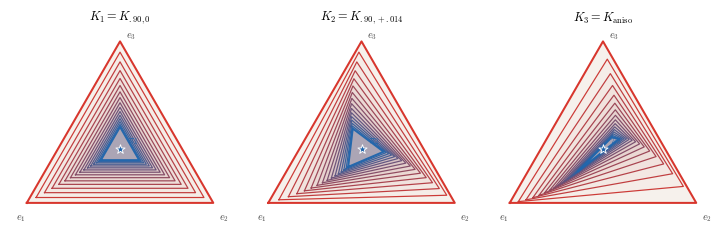

In [4]:
def draw_kernel_contraction(
    ax: plt.Axes,
    item: dict,
    kernel_index: int,
    max_power: int,
) -> None:
    """Draw nested images of the simplex for one Markov kernel.

    Args:
        ax: Matplotlib axes receiving the simplex geometry.
        item: Kernel, stationary law, and contraction diagnostics.
        kernel_index: One-based kernel label used in the panel title.
        max_power: Largest displayed iteration exponent.

    Returns:
        None. The axes are modified in place.
    """
    ax.fill(
        SIMPLEX_VERTICES[:, 0],
        SIMPLEX_VERTICES[:, 1],
        color="#f7f5f0",
        zorder=0,
    )

    for power in range(max_power + 1):
        triangle = simplex_image(item["kernel"], power)
        closed = np.vstack([triangle, triangle[0]])
        color = interp_color(power / max_power)
        ax.fill(
            triangle[:, 0],
            triangle[:, 1],
            color=color,
            alpha=0.018 + 0.040 * power / max_power,
            zorder=1 + power,
        )
        ax.plot(
            closed[:, 0],
            closed[:, 1],
            color=color,
            lw=1.45 if power in (0, max_power) else 0.86,
            alpha=0.97,
            solid_joinstyle="round",
            zorder=10 + power,
        )

    stationary_xy = barycentric_to_plane(item["stationary"])
    ax.scatter(
        [stationary_xy[0]],
        [stationary_xy[1]],
        marker="*",
        s=48,
        color=BLUE,
        edgecolor="white",
        linewidth=0.65,
        zorder=30,
    )
    ax.annotate(
        rf"$\pi_{kernel_index}$",
        stationary_xy,
        xytext=(5, 5),
        textcoords="offset points",
        color=BLUE,
        fontsize=7.8,
        fontweight="bold",
        zorder=31,
    )

    vertex_offsets = [(-8, -12), (4, -12), (4, 3)]
    for vertex_index, (vertex, offset) in enumerate(
        zip(SIMPLEX_VERTICES, vertex_offsets),
        start=1,
    ):
        ax.annotate(
            rf"$e_{vertex_index}$",
            vertex,
            xytext=offset,
            textcoords="offset points",
            color=GRAY,
            fontsize=7.3,
        )

    ax.set_title(
        item["title"],
        fontsize=8.8,
        pad=1.8,
    )
    ax.set_aspect("equal")
    ax.set_xlim(-0.09, 1.09)
    ax.set_ylim(-0.14, 0.95)
    remove_axes(ax)


def render_figure(max_power: int = MAX_POWER) -> plt.Figure:
    """Render and export the three Birkhoff simplex-contraction panels.

    Args:
        max_power: Largest exponent ell displayed in K^ell Sigma_3.

    Returns:
        Matplotlib figure containing the three nested-simplex diagrams.
    """
    figure, axes = plt.subplots(1, 3, figsize=(7.25, 2.35))
    for index, (ax, item) in enumerate(zip(axes, KERNELS), start=1):
        draw_kernel_contraction(ax, item, index, max_power)

    figure.subplots_adjust(
        left=0.012,
        right=0.988,
        bottom=0.035,
        top=0.90,
        wspace=0.075,
    )

    save_pdf(figure, OUT / "simplex-contraction.pdf", pad_inches=0.035)
    THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(
        THUMBNAIL,
        dpi=220,
        bbox_inches="tight",
        pad_inches=0.04,
        facecolor="white",
    )
    return figure


FIGURE = render_figure()
plt.show()

## Figure preview

The exported thumbnail below is generated from the same vector figure used by the manuscript.

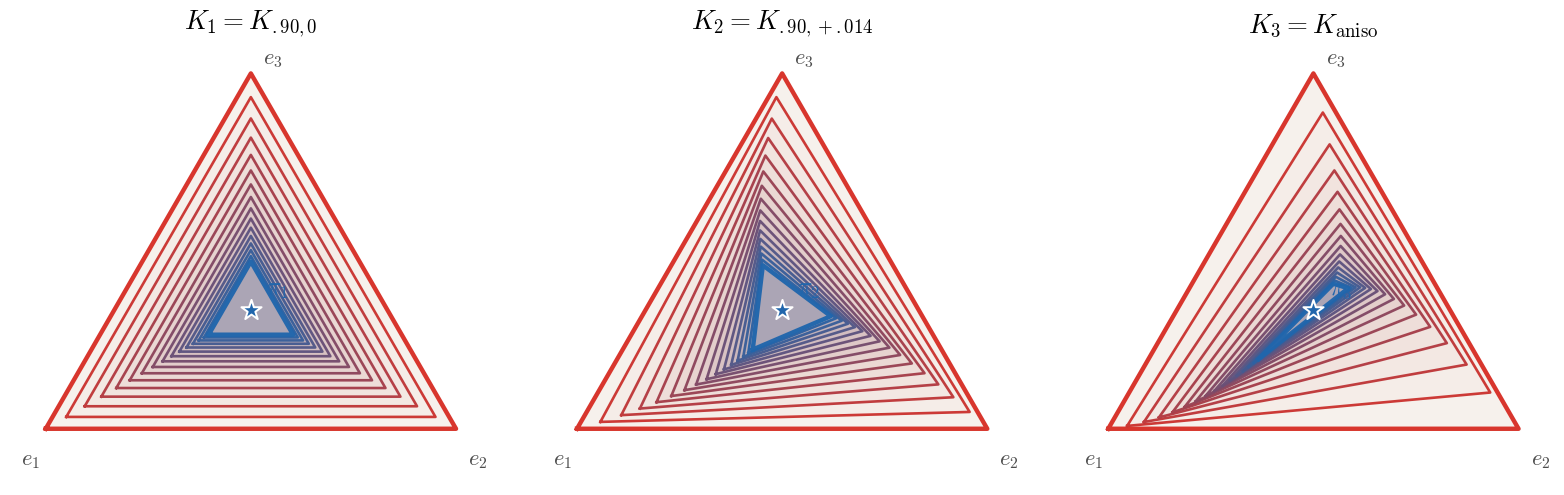

In [5]:
from IPython.display import Image, display

if Path(THUMBNAIL).exists():
    display(Image(filename=str(THUMBNAIL)))
else:
    print("Optional preview is unavailable; the numerical outputs above remain complete.")
